In [40]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, PrecisionRecallDisplay, average_precision_score
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupKFold

In [2]:
from txn_pipeline import run_pipeline
df = run_pipeline()

/Users/shinsuke.adachi/.pyenv/versions/3.8.16/lib/python3.8/site-packages/google/cloud/bigquery_storage_v1/__init__.py:57: FutureWarning: You are using a non-supported Python version (3.8.16).  Google will not post any further updates to google.cloud.bigquery_storage_v1 supporting this Python version. Please upgrade to the latest Python version, or at least to Python 3.9, and then update google.cloud.bigquery_storage_v1.
  warnings.warn(
/Users/shinsuke.adachi/.pyenv/versions/3.8.16/lib/python3.8/site-packages/pgeocode.py:236: UserWarning: The Argentina data file contains 4-digit postal codes which were replaced with a new system in 1999.
  warnings.warn(


In [3]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder

In [17]:
def engineer_dunning_features(df):
    # 1. Filter for soft decline and dunning attempts
    df = df.sort_values(by = ['linked_invoice_id', 'updated_at'])
    df['prev_decline_code'] = df.groupby(['linked_invoice_id'])['Decline_code_norm'].shift(periods=1)
    df['prev_card_status'] = df.groupby(['linked_invoice_id'])['card_status'].shift(periods=1)
    # df['prev_decline_seller_message'] = df.groupby(['linked_invoice_id'])['outcome_seller_message'].shift(periods=1)

    df['prev_decline_type'] = df.groupby(['linked_invoice_id'])['Decline_type_for_retry'].shift(periods=1)
    df['prev_attempt_time'] = df.groupby(['linked_invoice_id'])['updated_at'].shift(periods=1)
    df['time_since_prev_attempt'] = (df['updated_at'] - df['prev_attempt_time']).dt.total_seconds() / 3600

    df['first_attempt_at'] = df.groupby('linked_invoice_id')['updated_at'].transform('min')
    df['cumulative_delay_hours'] = (df['updated_at'] - df['first_attempt_at']).dt.total_seconds() / 3600

    df = df[(df['is_attached_invoice_1st_attempt']=='Dunning attempt') & (df['prev_decline_type']=='Soft decline')]
    
    df['local_day_of_week'] = df['localized_time'].dt.dayofweek
    # --- TEMPORAL FEATURES (Cyclical Encoding) ---
    # Convert hour and day into coordinates on a circle so 23:00 is close to 00:00
    df['hour_sin'] = np.sin(2 * np.pi * df['local_hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['local_hour'] / 24)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['local_day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['local_day_of_week'] / 7)

    df['max_days'] = df['localized_time'].dt.days_in_month
    df['day_sin'] = np.sin(2 * np.pi * (df['local_day_of_month'] - 1) / df['max_days'])
    df['day_cos'] = np.cos(2 * np.pi * (df['local_day_of_month'] - 1) / df['max_days'])
    
    # --- FINANCIAL CONTEXT (The "Payday" Effect) --
    # Calculate distance to common paydays (1st and 15th)
    df['dist_to_payday'] = df['local_day_of_month'].apply(
        lambda x: min(abs(x - 1), abs(x - 15), abs(x - 30))
    )
    
    # --- TRANSACTIONAL SIGNALS ---
    # Log transform charge amount to handle outliers/skewness
    df['log_charge_amount'] = np.log1p(df['amount'])
    
    # Binary flag for debit vs credit (debit is high-sensitivity for timing)
    df['is_debit'] = (df['funding_type_norm'].str.lower() == 'debit').astype(int)
    

    # --- BEHAVIORAL ---
    # Attempt fatigue: Probability of success usually drops as attempt_no increases
    # We can create a ratio: charge_amount per attempt
    df['amt_per_attempt'] = df['amount'] / (df['invoice_attempt_no'] + 1)


    df['is_success'] = (df['status']=='success').astype(int)

    df['billing_country'] = df['billing_country'].fillna('UNKNOWN').astype(str)
    df['prev_decline_code'] = df['prev_decline_code'].fillna('UNKNOWN').astype(str)

    return df


In [18]:
processed_df = engineer_dunning_features(df)

In [19]:
keep_cols = ['linked_invoice_id', 'prev_decline_code', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'day_sin', 'day_cos',
            'dist_to_payday', 'log_charge_amount', 'is_debit', 'amt_per_attempt', 'time_since_prev_attempt', 'cumulative_delay_hours', 
            'billing_country', 'gateway', 'funding_type_norm', 'card_brand', 'prev_card_status', 'Domain_category', 'invoice_attempt_no',
            'is_success']
df_dunning = processed_df[keep_cols]

## Baseline

**Current setup:** GroupKFold(5) by `linked_invoice_id`, CatBoost (AUC early stop), no class weighting, final `model` is from last fold only.

**Issues that limit accuracy / deployment:**
1. **Class imbalance** — PR-AUC ~0.17 indicates few successes; default CatBoost treats classes equally.
2. **No temporal validation** — CV is random by invoice; in production we score future attempts, so a time-based holdout (train on past, test on future) better reflects performance.
3. **Final model** — Only the last fold’s model is kept; for production we should refit on full data.
4. **Single metric** — AUC is optimized; for recovery, PR-AUC or F2 may better match business impact.
5. **Threshold** — Optimal F2 threshold is computed on one fold’s test set; should be cross-validated or use a dedicated validation set.

**Improvements applied below:** class weighting (`auto_class_weights='Balanced'`), optional time-based split (`USE_TIME_SPLIT=True`), refit on full data for production, and PR-AUC reporting.

**Further improvements to try:** (1) Cross-validate the F2 threshold (e.g. per-fold threshold, then average). (2) Hyperparameter tuning (e.g. Optuna over depth, lr, l2_leaf_reg). (3) Decline-code or country-specific features / separate models for high-volume segments. (4) Probability calibration (`CalibratedClassifierCV`) for better EV in Option A.

In [12]:
target = 'is_success'
group_col = 'linked_invoice_id'

# Define features to drop (IDs, targets, and raw timestamps)
drop_cols = [target, group_col] # 'amount' dropped if you use 'log_charge_amount'

# Identify categorical features for CatBoost
cat_features = [
    'prev_decline_code', 'billing_country', 'gateway', 
    'funding_type_norm', 'card_brand', 'Domain_category'
]

X = df_dunning.drop(columns=drop_cols)
y = df_dunning[target]
groups = df_dunning[group_col]

# Optional: time-based holdout (train on past, test on future) — better reflects deployment
USE_TIME_SPLIT = True  # set True to validate on last 20% of time instead of GroupKFold
if USE_TIME_SPLIT and 'updated_at' in processed_df.columns:
    attempt_dates = processed_df.loc[df_dunning.index, 'updated_at']
    cutoff = attempt_dates.quantile(0.80)
    train_mask = (attempt_dates < cutoff).values
else:
    train_mask = None

# 2. Setup Grouped Cross-Validation (or single time split)
gkf = GroupKFold(n_splits=5)
auc_scores = []
pr_auc_scores = []

print(f"Starting Training on {len(X)} rows...")
print(f"Class balance: {y.mean():.4f} positive (use class weighting for imbalanced recovery)")

# 3. Training Loop (skip CV when using time-based split)
if train_mask is not None:
    X_train, X_test = X.loc[train_mask], X.loc[~train_mask]
    y_train, y_test = y.loc[train_mask], y.loc[~train_mask]
    model = CatBoostClassifier(
        iterations=1000, learning_rate=0.05, depth=6, eval_metric='AUC',
        random_seed=42, verbose=100, early_stopping_rounds=50,
        auto_class_weights='Balanced',
    )
    model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), use_best_model=True)
    preds = model.predict_proba(X_test)[:, 1]
    auc_scores.append(roc_auc_score(y_test, preds))
    pr_auc_scores.append(average_precision_score(y_test, preds))
    print(f"Time-based holdout | AUC: {auc_scores[0]:.4f} | PR-AUC: {pr_auc_scores[0]:.4f}")
else:
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Initialize CatBoost — auto_class_weights='Balanced' improves PR-AUC on imbalanced dunning
        model = CatBoostClassifier(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            eval_metric='AUC',
            random_seed=42,
            verbose=100,
            early_stopping_rounds=50,
            auto_class_weights='Balanced',  # weight positives higher to improve recovery ranking
        )
        
        # Fit model
        model.fit(
            X_train, y_train,
            cat_features=cat_features,
            eval_set=(X_test, y_test),
            use_best_model=True
        )
        
        # Evaluate (PR-AUC is key for imbalanced recovery)
        preds = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, preds)
        pr_auc = average_precision_score(y_test, preds)
        
        auc_scores.append(auc)
        pr_auc_scores.append(pr_auc)
        print(f"Fold {fold+1} | AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}")

print(f"\nFinal Cross-Validation Results:")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")
print(f"Mean PR-AUC: {np.mean(pr_auc_scores):.4f}")

# 4. Refit final model on full data for production (Option A uses this model)
# Use a 10% random holdout as eval_set so early stopping works (avoids "use_best_model switched to false" warning)
print("\nRefitting final model on full data...")
from sklearn.model_selection import train_test_split
X_fit, X_eval, y_fit, y_eval = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    auto_class_weights='Balanced',
)
model.fit(X_fit, y_fit, cat_features=cat_features, eval_set=(X_eval, y_eval), use_best_model=True)
print("Done. Use this model for recommend_timing_for_invoices.")

Starting Training on 1079271 rows...
Class balance: 0.0176 positive (use class weighting for imbalanced recovery)
0:	test: 0.6697194	best: 0.6697194 (0)	total: 606ms	remaining: 10m 5s
100:	test: 0.7344572	best: 0.7345301 (99)	total: 30.3s	remaining: 4m 30s
200:	test: 0.7465352	best: 0.7465597 (196)	total: 1m 1s	remaining: 4m 4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7465597243
bestIteration = 196

Shrink model to first 197 iterations.
Time-based holdout | AUC: 0.7466 | PR-AUC: 0.0924

Final Cross-Validation Results:
Mean AUC: 0.7466
Mean PR-AUC: 0.0924

Refitting final model on full data...
0:	test: 0.7659255	best: 0.7659255 (0)	total: 350ms	remaining: 5m 50s
100:	test: 0.8229728	best: 0.8229728 (100)	total: 32.6s	remaining: 4m 50s
200:	test: 0.8367569	best: 0.8367569 (200)	total: 1m 1s	remaining: 4m 4s
300:	test: 0.8443471	best: 0.8443907 (296)	total: 1m 31s	remaining: 3m 33s
400:	test: 0.8495420	best: 0.8495420 (400)	total: 2m 4s	remaining: 3m 5s
500:	tes

## Probability calibration

Wrap the refitted model in `CalibratedClassifierCV` (isotonic) so predicted probabilities are better calibrated. Fit the calibrator on the 10% eval set. Use the calibrated model for Option A and threshold decisions.

In [26]:
# Step 3: CalibratedClassifierCV on the refitted model (fit calibrator on eval set)
from sklearn.calibration import CalibratedClassifierCV

# Use the main refitted model; calibrator fitted on (X_eval, y_eval)
calibrated_model = CalibratedClassifierCV(model, cv="prefit", method="isotonic")
calibrated_model.fit(X_eval, y_eval)

preds_cal = calibrated_model.predict_proba(X_eval)[:, 1]
pr_auc_cal = average_precision_score(y_eval, preds_cal)
print(f"Calibrated model | PR-AUC (eval): {pr_auc_cal:.4f}")

Calibrated model | PR-AUC (eval): 0.1453


## Strict temporal validation and threshold selection

**Strict temporal validation:** Train on data before a fixed date, evaluate on a **fixed holdout window** (e.g. last 14 days) that is never used in training. This gives an unbiased estimate of production performance.

**Threshold and business metric:**
1. **F2-optimal threshold** — Tune the decision threshold on a **validation period** (e.g. 2 weeks before holdout) to maximize F2 (recall-weighted), then report precision/recall/F2 on the holdout.
2. **Business metric** — Optionally maximize **recovered revenue − (cost per attempt × number of attempts)** over thresholds on the validation set; evaluate on holdout. Uses `amount` from `processed_df` for revenue.

In [55]:
# --- Strict temporal validation and threshold selection (best model) ---
import pandas as pd

HOLDOUT_DAYS = 30   # last N days for holdout (never seen in training)
VAL_DAYS = 30       # period before holdout used only for threshold tuning

attempt_dates = processed_df.loc[df_dunning.index, "updated_at"]
if not pd.api.types.is_datetime64_any_dtype(attempt_dates):
    attempt_dates = pd.to_datetime(attempt_dates)

holdout_end = attempt_dates.max()
holdout_start = holdout_end - pd.Timedelta(days=HOLDOUT_DAYS)
val_end = holdout_start
val_start = val_end - pd.Timedelta(days=VAL_DAYS)

train_mask = (attempt_dates < val_start).values
val_mask = ((attempt_dates >= val_start) & (attempt_dates < holdout_start)).values
holdout_mask = (attempt_dates >= holdout_start).values

X_train_t, X_val, X_hold = X.loc[train_mask], X.loc[val_mask], X.loc[holdout_mask]
y_train_t, y_val, y_hold = y.loc[train_mask], y.loc[val_mask], y.loc[holdout_mask]

print(f"Strict temporal split:")
print(f"  Train: {X_train_t.shape[0]} rows (before {val_start.date()})")
print(f"  Val:   {X_val.shape[0]} rows ({val_start.date()} to {val_end.date()})")
print(f"  Holdout: {X_hold.shape[0]} rows (last {HOLDOUT_DAYS} days)")

# Train best model (CatBoost balanced) on train only, early stop on val
# Train base model WITHOUT auto_class_weights to avoid probability distortion (calibration applied below)
model_temporal = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6, eval_metric="AUC",
    random_seed=42, verbose=50, early_stopping_rounds=50,
)
model_temporal.fit(
    X_train_t, y_train_t,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

preds_val = model_temporal.predict_proba(X_val)[:, 1]
preds_hold = model_temporal.predict_proba(X_hold)[:, 1]

# Holdout PR-AUC (unbiased)
pr_auc_hold = average_precision_score(y_hold, preds_hold)
print(f"\nHoldout PR-AUC: {pr_auc_hold:.4f}")

# --- F2-optimal threshold (tuned on val, evaluated on holdout) ---
prec_val, rec_val, thresh_val = precision_recall_curve(y_val, preds_val)
with np.errstate(divide="ignore", invalid="ignore"):
    f2_val = (5 * prec_val[:-1] * rec_val[:-1]) / (4 * prec_val[:-1] + rec_val[:-1])
best_idx = np.nanargmax(f2_val)
threshold_f2 = thresh_val[best_idx]

y_hold_pred_f2 = (preds_hold >= threshold_f2).astype(int)
from sklearn.metrics import precision_score, recall_score, fbeta_score
p_hold = precision_score(y_hold, y_hold_pred_f2, zero_division=0)
r_hold = recall_score(y_hold, y_hold_pred_f2, zero_division=0)
f2_hold = fbeta_score(y_hold, y_hold_pred_f2, beta=2, zero_division=0)

print(f"\nF2-optimal threshold (tuned on val): {threshold_f2:.4f}")
print(f"On holdout at this threshold: Precision={p_hold:.4f}, Recall={r_hold:.4f}, F2={f2_hold:.4f}")

# --- Business metric: recovered revenue − cost (tune threshold on val) ---
# Revenue = sum(amount) for recovered (y_true=1 and predicted positive); cost = cost_per_attempt * n_predicted_positive
if "amount" in processed_df.columns:
    amount_hold = processed_df.loc[X_hold.index, "amount"].values
    amount_val = processed_df.loc[X_val.index, "amount"].values
    COST_PER_ATTEMPT = 0.10  # tunable: cost per dunning attempt (e.g. email/ops)
    thresh_candidates = np.percentile(preds_val, np.linspace(99, 50, 50))
    profit_val = []
    for t in thresh_candidates:
        pred_pos_val = preds_val >= t
        recovered = np.sum(amount_val[(y_val.values == 1) & pred_pos_val])
        cost = COST_PER_ATTEMPT * np.sum(pred_pos_val)
        profit_val.append(recovered - cost)
    best_t_idx = np.argmax(profit_val)
    threshold_biz = thresh_candidates[best_t_idx]
    pred_pos_hold = preds_hold >= threshold_biz
    recovered_hold = np.sum(amount_hold[(y_hold.values == 1) & pred_pos_hold])
    cost_hold = COST_PER_ATTEMPT * np.sum(pred_pos_hold)
    profit_hold = recovered_hold - cost_hold
    print(f"\nBusiness metric (cost_per_attempt={COST_PER_ATTEMPT}):")
    print(f"  Best threshold (on val): {threshold_biz:.4f}")
    print(f"  Holdout: recovered=${recovered_hold:,.0f}, cost=${cost_hold:,.0f}, profit=${profit_hold:,.0f}")
else:
    print("\n(No 'amount' in processed_df; skipping business-metric threshold.)")

# Optional: refit production model on train+val (no holdout) for deployment
# model_temporal.fit(X.loc[train_mask | val_mask], y.loc[train_mask | val_mask], ...)

Strict temporal split:
  Train: 916599 rows (before 2025-12-06)
  Val:   85379 rows (2025-12-06 to 2026-01-05)
  Holdout: 77293 rows (last 30 days)
0:	test: 0.5835773	best: 0.5835773 (0)	total: 619ms	remaining: 10m 18s
50:	test: 0.6856571	best: 0.6856571 (50)	total: 17.7s	remaining: 5m 28s
100:	test: 0.7076045	best: 0.7076045 (100)	total: 34.7s	remaining: 5m 8s
150:	test: 0.7178699	best: 0.7178699 (150)	total: 55.8s	remaining: 5m 13s
200:	test: 0.7227777	best: 0.7227777 (200)	total: 1m 15s	remaining: 4m 58s
250:	test: 0.7262025	best: 0.7262097 (239)	total: 1m 35s	remaining: 4m 43s
300:	test: 0.7273154	best: 0.7285348 (267)	total: 1m 53s	remaining: 4m 22s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7285347656
bestIteration = 267

Shrink model to first 268 iterations.

Holdout PR-AUC: 0.1091

F2-optimal threshold (tuned on val): 0.0649
On holdout at this threshold: Precision=0.0806, Recall=0.3885, F2=0.2202

Business metric (cost_per_attempt=0.1):
  Best threshold

### Probability calibration (fix distortion)
Fit **CalibratedClassifierCV** (isotonic) on the validation set so predicted probabilities are comparable across users. Use the calibrated model for ranking backtest and optimal-slot selection.

In [56]:
from sklearn.calibration import CalibratedClassifierCV

model_temporal_calibrated = CalibratedClassifierCV(model_temporal, cv="prefit", method="isotonic")
model_temporal_calibrated.fit(X_val, y_val)

# Use calibrated model for backtest and slot selection (better probability comparison across users)
preds_val_cal = model_temporal_calibrated.predict_proba(X_val)[:, 1]
print(f"Calibrated model | PR-AUC (val): {average_precision_score(y_val, preds_val_cal):.4f}")

Calibrated model | PR-AUC (val): 0.0677


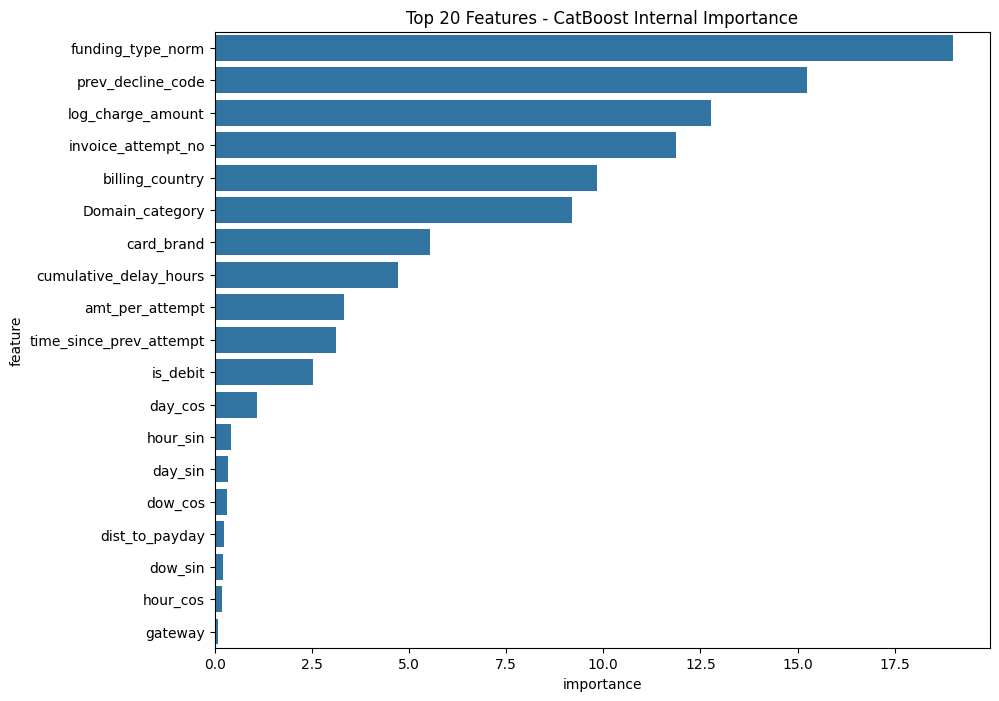

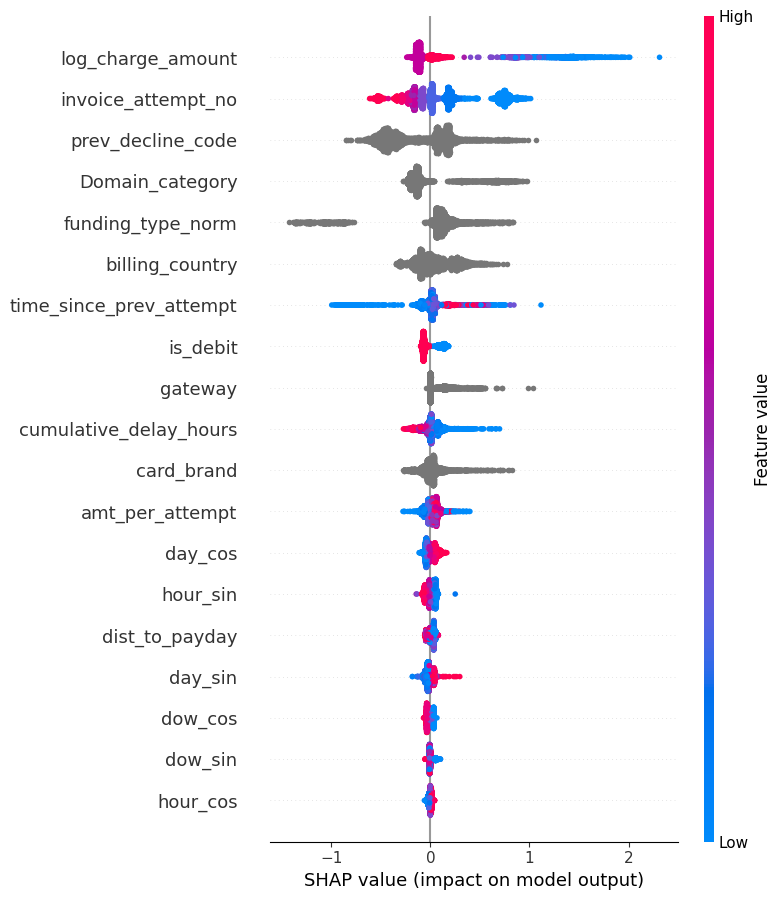

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Built-in CatBoost Importance
# This measures how much the loss function changes when a feature is used.
fi = model_temporal.get_feature_importance(type='FeatureImportance')
feature_names = X.columns
fi_df = pd.DataFrame({'feature': feature_names, 'importance': fi}).sort_values(by='importance', ascending=False)

# 2. SHAP Values (Directional Impact)
# We use a sample because calculating SHAP on 1M rows is computationally expensive.
import shap
explainer = shap.TreeExplainer(model_temporal)
shap_sample = X_test.sample(min(5000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(shap_sample)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=fi_df.head(20))
plt.title('Top 20 Features - CatBoost Internal Importance')
plt.show()

# SHAP Summary Plot
shap.summary_plot(shap_values, shap_sample)

### Should you evaluate each model on the holdout?

**Yes.** For a fair comparison, every candidate (Base, scale_pos_weight, Optuna, Calibrated) should be trained on the **same temporal train set** and evaluated on the **same holdout**. Otherwise you're comparing models trained on different data (e.g. full data vs train-only). The cell below trains each variant on the same split used for `model_temporal` and reports holdout PR-AUC (and optional recall at fixed precision) so you can choose the best model for production.

In [ ]:
# # --- Evaluate each model on the SAME holdout (run after strict temporal cell) ---
# # Uses: X_train_t, y_train_t, X_val, y_val, X_hold, y_hold, cat_features, model_temporal

# p_pos = y_train_t.mean()
# scale_pos_weight = (1 - p_pos) / p_pos if p_pos > 0 else 1.0

# # Optuna-style params (use study.best_params if you ran Optuna earlier; else defaults)
# try:
#     optuna_params = {k: v for k, v in best_params.items() if k in ["depth", "learning_rate", "l2_leaf_reg"]}
# except NameError:
#     optuna_params = {"depth": 7, "learning_rate": 0.1, "l2_leaf_reg": 7.0}

# models_holdout = []

# # 1. Base (already trained as model_temporal)
# preds_base_hold = model_temporal.predict_proba(X_hold)[:, 1]
# preds_base_val = model_temporal.predict_proba(X_val)[:, 1]
# models_holdout.append(("Base (balanced)", preds_base_hold, preds_base_val))

# # 2. scale_pos_weight (train on same train, eval on val)
# model_spw_t = CatBoostClassifier(
#     iterations=1000, learning_rate=0.05, depth=6, eval_metric="AUC",
#     random_seed=42, verbose=0, early_stopping_rounds=50,
#     scale_pos_weight=scale_pos_weight,
# )
# model_spw_t.fit(X_train_t, y_train_t, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True)
# models_holdout.append(("scale_pos_weight", model_spw_t.predict_proba(X_hold)[:, 1], model_spw_t.predict_proba(X_val)[:, 1]))

# # 3. Optuna params (train on same train, eval on val)
# model_opt_t = CatBoostClassifier(
#     iterations=1000, eval_metric="AUC", random_seed=42, verbose=0, early_stopping_rounds=50,
#     auto_class_weights="Balanced", **optuna_params,
# )
# model_opt_t.fit(X_train_t, y_train_t, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True)
# models_holdout.append(("Optuna (params)", model_opt_t.predict_proba(X_hold)[:, 1], model_opt_t.predict_proba(X_val)[:, 1]))

# # 4. Calibrated (base model_temporal + calibrator on val)
# from sklearn.calibration import CalibratedClassifierCV
# calibrated_t = CalibratedClassifierCV(model_temporal, cv="prefit", method="isotonic")
# calibrated_t.fit(X_val, y_val)
# models_holdout.append(("Calibrated", calibrated_t.predict_proba(X_hold)[:, 1], calibrated_t.predict_proba(X_val)[:, 1]))

# # Per-model F2-optimal threshold (tuned on val), then recoveries/attempts on holdout at that threshold
# def f2_threshold_on_val(y_val, preds_val):
#     p, r, t = precision_recall_curve(y_val, preds_val)
#     with np.errstate(divide="ignore", invalid="ignore"):
#         f2 = (5 * p[:-1] * r[:-1]) / (4 * p[:-1] + r[:-1])
#     return t[np.nanargmax(np.nan_to_num(f2, nan=0))]
# n_pos_hold = int(y_hold.sum())

# # Compare holdout PR-AUC, recall at 5% precision, recoveries and attempts at each model's F2 threshold
# min_prec = 0.05
# print("Holdout comparison (same train/val/holdout split):\n")
# print(f"{'Model':<22} {'PR-AUC':>8} {'Recall@P≥5%':>12} {'Recov@F2':>10} {'Attempts@F2':>12}")
# print("-" * 68)
# for item in models_holdout:
#     name, preds_hold, preds_val = item[0], item[1], item[2]
#     pr_auc = average_precision_score(y_hold, preds_hold)
#     p, r, _ = precision_recall_curve(y_hold, preds_hold)
#     idx = np.where(p[:-1] >= min_prec)[0]
#     rec_5 = r[idx[-1]] if len(idx) else 0
#     thresh = f2_threshold_on_val(y_val, preds_val)
#     pred_pos = (preds_hold >= thresh).astype(int)
#     recoveries = int(((y_hold.values == 1) & (pred_pos == 1)).sum())
#     attempts = int(pred_pos.sum())
#     print(f"{name:<22} {pr_auc:>8.4f} {rec_5:>11.1%} {recoveries:>10} {attempts:>12}")
# print("-" * 68)
# print(f"(Holdout positives: {n_pos_hold}. Recoveries/Attempts at each model's F2-optimal threshold tuned on val.)")
# best_name = max(models_holdout, key=lambda x: average_precision_score(y_hold, x[1]))[0]
# print(f"Best holdout PR-AUC: {best_name}")

Holdout comparison (same train/val/holdout split):

Model                    PR-AUC  Recall@P≥5%   Recov@F2  Attempts@F2
--------------------------------------------------------------------
Base (balanced)          0.1263        0.1%        405         3196
scale_pos_weight         0.1263        0.1%        405         3196
Optuna (params)          0.1256        0.1%        478         4291
Calibrated               0.1153        0.7%        405         3196
--------------------------------------------------------------------
(Holdout positives: 1251. Recoveries/Attempts at each model's F2-optimal threshold tuned on val.)
Best holdout PR-AUC: Base (balanced)


## Ranking Backtest & Optimal Slot Simulation

Evaluates the model's ability to **rank** candidate slots (24, 36, …, 120 hours after previous attempt; 9 slots) so we can maximize recall by picking the best slot per invoice. Uses `ranking_backtest.py`: Top-1 accuracy, rank distribution, optional TTR, and `generate_candidate_slots` for global-max slot search.

=== Ranking Backtest (holdout) ===

Recovered invoices (with ≥1 success): 1251
Top-1 Accuracy: 51.72% (success was model's #1 pick)
Rank distribution (1 = model's top):
rank_of_success
1    647
2    268
3    163
4    107
5     47
6     15
7      3
8      1
Name: count, dtype: int64

=== Time-to-Recovery (TTR) ===
Baseline (avg hours to recovery): 338.4
Model Top-1 (avg hours when success was rank #1): 258.8
% recovered where model ranked success #1: 51.7%


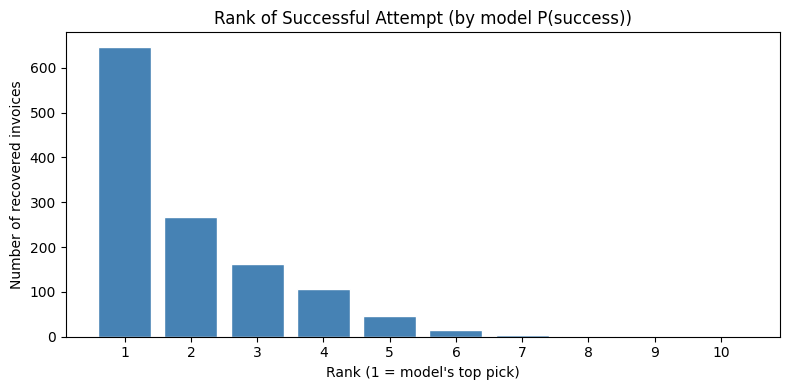


Optimal slot (global max) for sample invoice: slot #2, P(success)=0.0264
Slot probabilities (24h, 36h, ..., 120h after prev attempt):
[0.0197 0.0264 0.0264 0.0197 0.0177 0.0177 0.0158 0.0197 0.0197 0.0197
 0.0197 0.0177 0.0197 0.0197 0.0197 0.0197 0.0197 0.0197 0.0197 0.0197
 0.0197 0.0197 0.0197 0.0197 0.0211]

Proportion of #1 rank by time slot (share of recovered invoices where model picked this slot as best):


,proportion
24h,0.308553
28h,0.072742
32h,0.029576
36h,0.032774
40h,0.011990
44h,0.012790
48h,0.004796
52h,0.147882
56h,0.073541
60h,0.043165


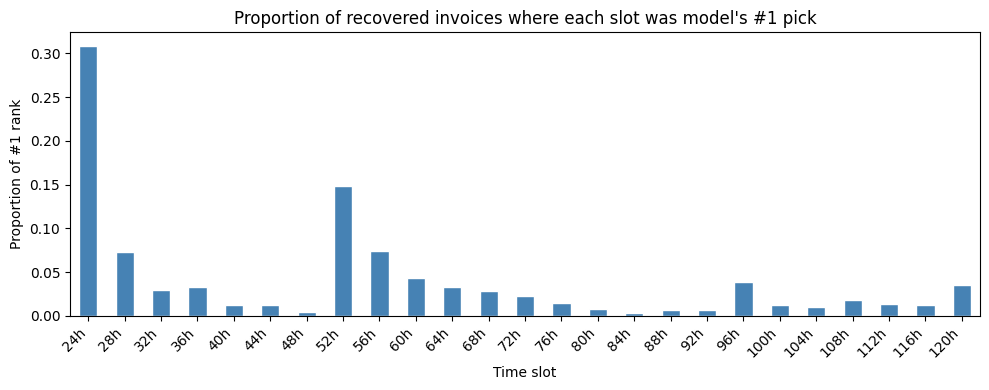

In [58]:
# --- Ranking Backtest (run after strict temporal + holdout comparison) ---
# Uses calibrated model for comparable probabilities across users.
# Requires: X_hold, y_hold, model_temporal_calibrated, cat_features, df_dunning (for linked_invoice_id)
# Optional: processed_df (for updated_at, first_attempt_at) for TTR
import ranking_backtest
from ranking_backtest import (
    run_full_backtest,
    run_ranking_backtest,
    top1_accuracy,
    rank_distribution,
    plot_rank_distribution,
    generate_candidate_slots,
    optimal_slot_for_invoice,
    rank1_slot_per_invoice,
    rank1_slot_labels,
    DEFAULT_DELAY_HOURS,
)
ranking_backtest = importlib.reload(ranking_backtest)


invoice_ids_hold = df_dunning.loc[X_hold.index, "linked_invoice_id"]
holdout_ts = None
if "updated_at" in processed_df.columns and "first_attempt_at" in processed_df.columns:
    holdout_ts = processed_df.loc[X_hold.index, ["updated_at", "first_attempt_at"]].copy()

model_for_backtest = model_temporal_calibrated  # calibrated probabilities for slot comparison
backtest_df = run_full_backtest(
    X_hold, y_hold, invoice_ids_hold, model_for_backtest, cat_features,
    holdout_timestamps=holdout_ts,
    max_rank=10,
    plot=True,
)

# --- Optimal Slot Simulation: find global max for one invoice (24h–120h slots) ---
if len(backtest_df) > 0:
    sample_inv = backtest_df.iloc[0]["invoice_id"]
    sample_idx = X_hold.index[invoice_ids_hold == sample_inv][0]
    invoice_row = X_hold.loc[sample_idx]
    base_ts = processed_df.loc[sample_idx, "updated_at"] if "updated_at" in processed_df.columns else pd.Timestamp.now()
    first_ts = processed_df.loc[sample_idx, "first_attempt_at"] if "first_attempt_at" in processed_df.columns else None
    slot_num, max_p, slots_df = optimal_slot_for_invoice(
        invoice_row, pd.Timestamp(base_ts), model_for_backtest, cat_features,
        first_attempt_timestamp=pd.Timestamp(first_ts) if first_ts is not None else None,
    )
    print(f"\nOptimal slot (global max) for sample invoice: slot #{slot_num}, P(success)={max_p:.4f}")
    print("Slot probabilities (24h, 36h, ..., 120h after prev attempt):")
    print(slots_df["prob"].values.round(4))

# --- Proportion of #1 rank per time slot (24h–120h after prev attempt) ---
if len(backtest_df) > 0 and holdout_ts is not None:
    rank1_slots = rank1_slot_per_invoice(backtest_df, X_hold, invoice_ids_hold, holdout_ts, model_for_backtest, cat_features)
    if len(rank1_slots) > 0:
        n_slots = len(DEFAULT_DELAY_HOURS)
        slot_labels = rank1_slot_labels()
        prop_rank1 = rank1_slots.value_counts(normalize=True).sort_index()
        prop_rank1 = prop_rank1.reindex(range(n_slots), fill_value=0.0)
        prop_rank1.index = [slot_labels[i] for i in range(n_slots)]
        print("\nProportion of #1 rank by time slot (share of recovered invoices where model picked this slot as best):")
        display(prop_rank1.to_frame("proportion"))
        fig, ax = plt.subplots(figsize=(10, 4))
        prop_rank1.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
        ax.set_xlabel("Time slot")
        ax.set_ylabel("Proportion of #1 rank")
        ax.set_title("Proportion of recovered invoices where each slot was model's #1 pick")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

### Circadian bias diagnostic
Compare localized hour of **initial failure** vs **model's predicted optimal slot**. Clock-time shift and **shuffle test**: if rank-1 slot distribution is similar when `hour_sin`/`hour_cos` are shuffled, bias is in delay (e.g. time_since_prev_attempt), not clock time.

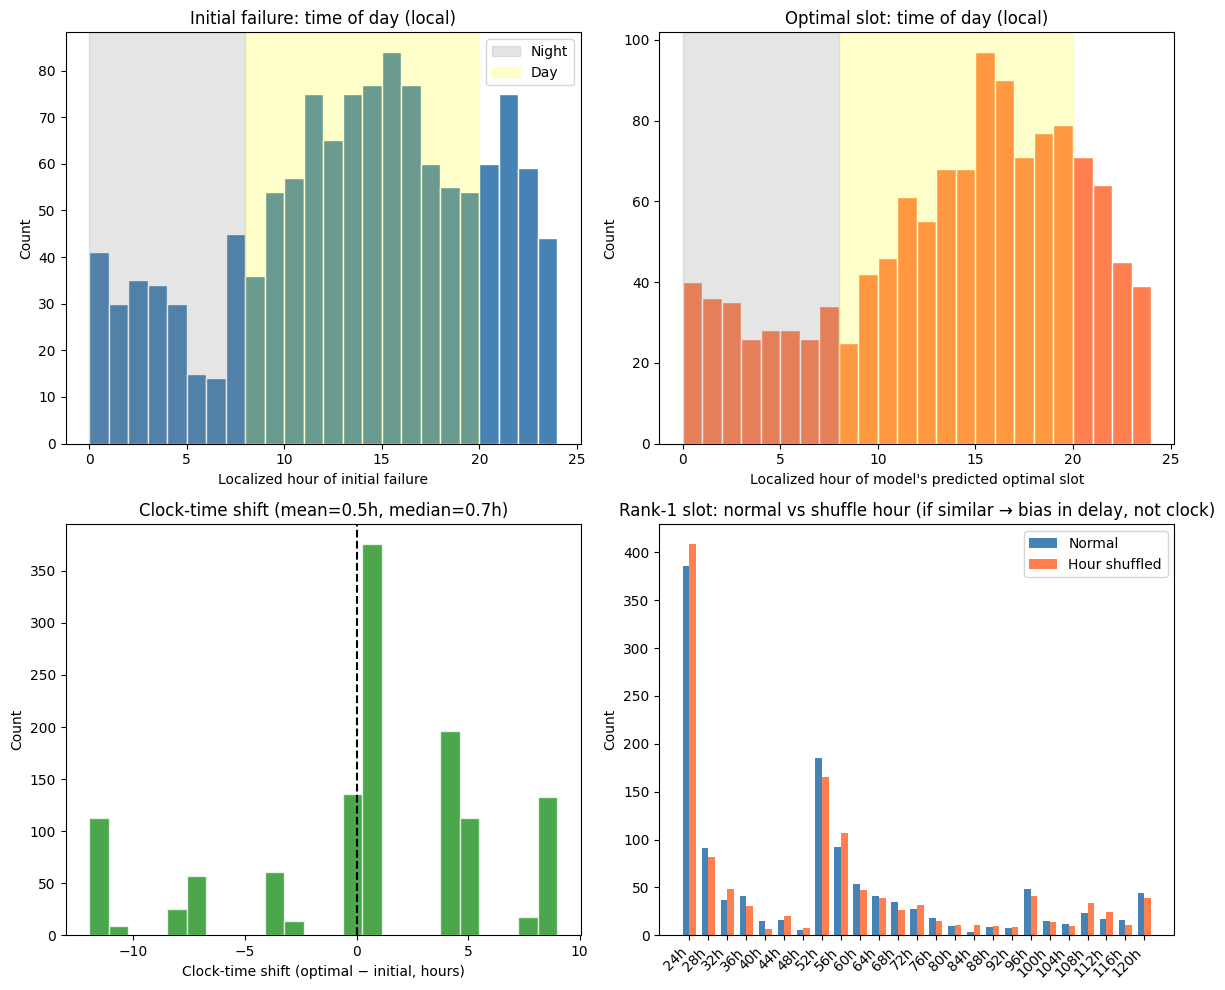

--- Circadian bias diagnostic ---
Clock-time shift (hours): mean = 0.51, median = 0.66
% of initial failures in Day (8–20h) for which optimal slot is Night: 23.9%

Rank-1 slot distribution (normal): {'24h': 386, '52h': 185, '56h': 92, '28h': 91, '60h': 54, '96h': 48, '120h': 44, '36h': 41, '64h': 41, '32h': 37, '68h': 35, '72h': 28, '108h': 23, '76h': 18, '112h': 17, '116h': 16, '44h': 16, '100h': 15, '40h': 15, '104h': 12, '80h': 10, '88h': 9, '92h': 8, '48h': 6, '84h': 4}
Rank-1 slot distribution (hour_sin/hour_cos shuffled): {'24h': 409, '52h': 165, '56h': 107, '28h': 82, '32h': 48, '60h': 47, '96h': 41, '120h': 39, '64h': 39, '108h': 34, '72h': 32, '36h': 31, '68h': 27, '112h': 24, '44h': 20, '76h': 15, '100h': 14, '80h': 11, '84h': 11, '116h': 11, '88h': 10, '104h': 10, '92h': 9, '48h': 8, '40h': 7}

Shuffle test: If the two distributions are very similar, the model is largely using delay (time_since_prev_attempt), not clock time.


In [59]:
if len(backtest_df) > 0 and holdout_ts is not None and "timezone" in processed_df.columns:
    import circadian_bias_diagnostic as cbd
    import importlib
    importlib.reload(cbd)
    diag_df, cbd_results = cbd.run_circadian_diagnostic(
        backtest_df, X_hold, invoice_ids_hold, holdout_ts, processed_df,
        model_for_backtest, cat_features,
    )
    if len(diag_df) > 0:
        cbd.plot_circadian_diagnostic(diag_df, cbd_results)
        cbd.run_shuffle_test_summary(diag_df, cbd_results)
else:
    print("Skipping circadian diagnostic: need backtest_df, holdout_ts, and processed_df with timezone.")